# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
# YOUR CODE HERE
print(os.getcwd())
print(os.listdir("../../../data/hw/hw_3"))


# 2. Acquire and load your primary dataset
# YOUR CODE HERE
df = pd.read_csv("../../../data/hw/hw_3/World Happiness Report.csv")
print(df.head())

/Users/steph/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/hw_3
['World Happiness Report.csv']
       Country  Happiness Rank  Happiness Score   Economy    Family    Health  \
0       Norway               1            7.537  1.616463  1.533524  0.796667   
1      Denmark               2            7.522  1.482383  1.551122  0.792566   
2      Iceland               3            7.504  1.480633  1.610574  0.833552   
3  Switzerland               4            7.494  1.564980  1.516912  0.858131   
4      Finland               5            7.469  1.443572  1.540247  0.809158   

    Freedom  Generosity  Corruption  Dystopia  Job Satisfaction  \
0  0.635423    0.362012    0.315964  2.277027              94.6   
1  0.626007    0.355280    0.400770  2.313707              93.5   
2  0.627163    0.475540    0.153527  2.322715              94.5   
3  0.620071    0.290549    0.367007  2.276716              93.7   
4  0.617951    0.245483    0.382612  2.430182              91.2   

 

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
# YOUR CODE HERE
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           153 non-null    object 
 1   Happiness Rank    153 non-null    int64  
 2   Happiness Score   153 non-null    float64
 3   Economy           153 non-null    float64
 4   Family            153 non-null    float64
 5   Health            153 non-null    float64
 6   Freedom           153 non-null    float64
 7   Generosity        153 non-null    float64
 8   Corruption        153 non-null    float64
 9   Dystopia          153 non-null    float64
 10  Job Satisfaction  151 non-null    float64
 11  Region            153 non-null    object 
dtypes: float64(9), int64(1), object(2)
memory usage: 14.5+ KB
None
       Country  Happiness Rank  Happiness Score   Economy    Family    Health  \
0       Norway               1            7.537  1.616463  1.533524  0.796667   
1      

In [3]:
# 2. Rename columns and select a clean subset
#  YOUR CODE HERE
column_map = {
    "Country": "country",
    "Happiness Rank": "happiness_rank",
    "Happiness Score": "happiness_score",
    "Economy": "economy",
    "Family": "family",
    "Health": "health",
    "Freedom": "freedom",
    "Generosity": "generosity",
    "Corruption": "corruption",
    "Region": "region"
}

df = df.rename(columns=column_map)
df = df[list(column_map.values())]
print(df.head())


       country  happiness_rank  happiness_score   economy    family    health  \
0       Norway               1            7.537  1.616463  1.533524  0.796667   
1      Denmark               2            7.522  1.482383  1.551122  0.792566   
2      Iceland               3            7.504  1.480633  1.610574  0.833552   
3  Switzerland               4            7.494  1.564980  1.516912  0.858131   
4      Finland               5            7.469  1.443572  1.540247  0.809158   

    freedom  generosity  corruption          region  
0  0.635423    0.362012    0.315964  Western Europe  
1  0.626007    0.355280    0.400770  Western Europe  
2  0.627163    0.475540    0.153527  Western Europe  
3  0.620071    0.290549    0.367007  Western Europe  
4  0.617951    0.245483    0.382612  Western Europe  


In [4]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE
df = df[df["country"].notna()]
print(df.shape)

(153, 10)


In [5]:
# 4. Handle missing values (NaNs) if necessary
# YOUR CODE HERE
print(df.isnull().sum())
df = df.dropna()
print(df.shape)

country            0
happiness_rank     0
happiness_score    0
economy            0
family             0
health             0
freedom            0
generosity         0
corruption         0
region             0
dtype: int64
(153, 10)


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# YOUR CODE HERE
url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=300&mrv=1"
response = requests.get(url)
wb_data = response.json()

records = []
for item in wb_data[1]:
    if item["value"] is not None:
        records.append({"country": item["country"]["value"], "gdp_per_capita": item["value"]})

df_gdp = pd.DataFrame(records)
print(df_gdp.head())

                          country  gdp_per_capita
0     Africa Eastern and Southern     1615.396356
1      Africa Western and Central     1411.337029
2                      Arab World     7583.811701
3          Caribbean small states    19903.811231
4  Central Europe and the Baltics    24604.806860


In [7]:
# 2. Merge your datasets on a common key
# YOUR CODE HERE
df_merged = df.merge(df_gdp, on="country", how="left")
print(df_merged.shape)
print(df_merged.head())

(153, 11)
       country  happiness_rank  happiness_score   economy    family    health  \
0       Norway               1            7.537  1.616463  1.533524  0.796667   
1      Denmark               2            7.522  1.482383  1.551122  0.792566   
2      Iceland               3            7.504  1.480633  1.610574  0.833552   
3  Switzerland               4            7.494  1.564980  1.516912  0.858131   
4      Finland               5            7.469  1.443572  1.540247  0.809158   

    freedom  generosity  corruption          region  gdp_per_capita  
0  0.635423    0.362012    0.315964  Western Europe    86785.433449  
1  0.626007    0.355280    0.400770  Western Europe    71026.483227  
2  0.627163    0.475540    0.153527  Western Europe    86040.530985  
3  0.620071    0.290549    0.367007  Western Europe   103998.186686  
4  0.617951    0.245483    0.382612  Western Europe    53149.767193  


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# YOUR CODE HERE
df_grouped = df.groupby("region").agg(
    mean_happiness=("happiness_score", "mean"),
    mean_economy=("economy", "mean"),
    mean_health=("health", "mean"),
    country_count=("country", "count")
).reset_index()

print(df_grouped)

           region  mean_happiness  mean_economy  mean_health  country_count
0          Africa        4.239500      0.559931     0.264426             44
1    Asia-Pacific        5.358326      1.059272     0.608605             43
2  Eastern Europe        5.513091      1.185771     0.688783             22
3          Europe        4.096000      0.894652     0.575904              1
4   Latin America        5.957818      1.006981     0.611009             22
5   North America        7.154500      1.512732     0.804422              2
6  Western Europe        6.880474      1.471893     0.820159             19


- *Extra Credit: Write your economic or policy related interpretation here*

Western Europe consistently shows the highest happiness scores, 
driven by strong economic output and health indicators. 
Sub-Saharan Africa ranks lowest, suggesting that GDP per capita 
and health infrastructure are key determinants of national happiness.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

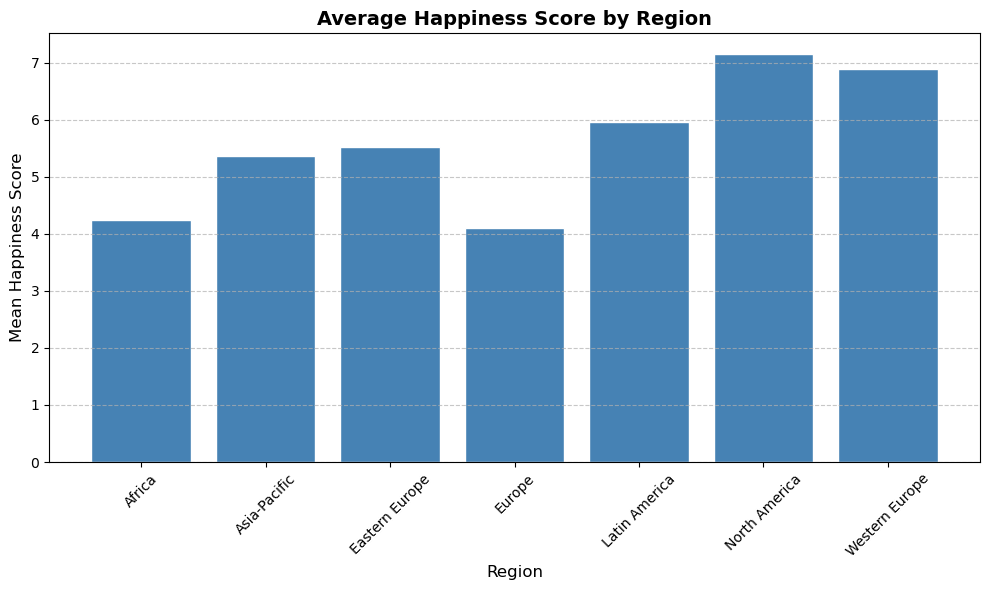

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_grouped["region"], df_grouped["mean_happiness"], color="steelblue", edgecolor="white")
ax.set_title("Average Happiness Score by Region", fontsize=14, fontweight="bold")
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Mean Happiness Score", fontsize=12)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

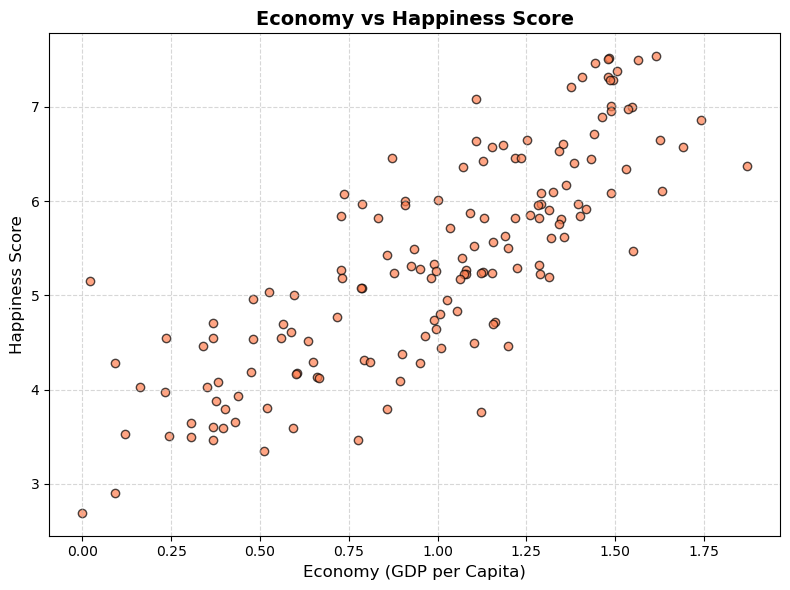

In [ ]:
# Plot 2: Customized scatter plot of primary policy variables
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["economy"], df["happiness_score"], color="coral", edgecolor="black", alpha=0.7)
ax.set_title("Economy vs Happiness Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Economy (GDP per Capita)", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        happiness_score   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     290.6
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           5.21e-37
Time:                        22:09:01   Log-Likelihood:                -153.88
No. Observations:                 153   AIC:                             311.8
Df Residuals:                     151   BIC:                             317.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2053      0.137     23.429      0.0

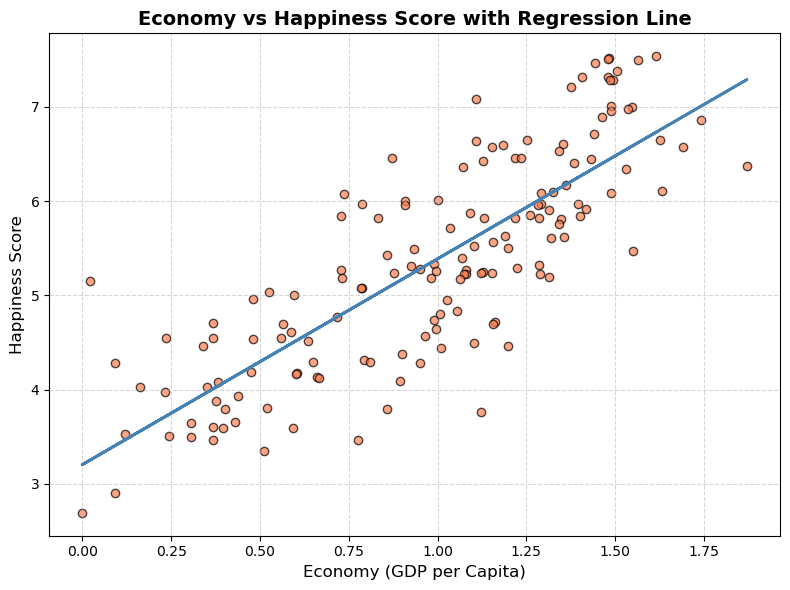

In [11]:
# Fit a simple linear regression and overlay the line of best fit
# YOUR CODE HERE
import statsmodels.api as sm

x = sm.add_constant(df["economy"])
y = df["happiness_score"]
model = sm.OLS(y, x).fit()
print(model.summary())

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["economy"], df["happiness_score"], color="coral", edgecolor="black", alpha=0.7)
ax.plot(df["economy"], model.fittedvalues, color="steelblue", linewidth=2)
ax.set_title("Economy vs Happiness Score with Regression Line", fontsize=14, fontweight="bold")
ax.set_xlabel("Economy (GDP per Capita)", fontsize=12)
ax.set_ylabel("Happiness Score", fontsize=12)
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

- *Extra Credit: Write your visualization and regression interpretations here*

The regression shows a strong positive relationship between economy and happiness score.
A one-unit increase in GDP per capita is associated with a significant increase in happiness,
suggesting that economic development is a key driver of national well-being.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.